# Zero-Shot Vehicle Classification with CLIP
- With out any images for few-shot, here we only use prompt

## Model

- **Backbone:** CLIP Vision Transformer (OpenAI CLIP)
- **Purpose:** Used as a feature extractor to obtain high-dimensional, semantically rich image embeddings.
- **Why CLIP?**  
  CLIP is trained on image-text pairs, enabling it to learn robust visual representations that generalize well, especially in low-data regimes.

---

In [1]:
import torch
import pandas as pd
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Loading CLIP model...")
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)

def predict_with_text_prompts(image_path, class_names):
    image = Image.open(image_path).convert("RGB")
    prompts = [f"An overhead satellite, drone, or aerial view of a {cls} parked on the ground." for cls in class_names]
    inputs = processor(text=prompts, images=image, return_tensors="pt", padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
        img_emb = outputs.image_embeds
        txt_emb = outputs.text_embeds
        img_emb = img_emb / img_emb.norm(p=2, dim=-1, keepdim=True)
        txt_emb = txt_emb / txt_emb.norm(p=2, dim=-1, keepdim=True)
        sims = torch.matmul(img_emb, txt_emb.T)
        best_idx = sims.argmax().item()
    return class_names[best_idx]

if __name__ == "__main__":
    # 1. Define your test set
    my_test_set = [
        (r"C:\Users\YASER\Documents\GitHub\Few-Shot-Vehicle-Detection-\test\sedan.png", "sedan"),
        (r"C:\Users\YASER\Documents\GitHub\Few-Shot-Vehicle-Detection-\test\SUV.png", "SUV"),
        (r"C:\Users\YASER\Documents\GitHub\Few-Shot-Vehicle-Detection-\test\bus.png", "bus"),
        (r"C:\Users\YASER\Documents\GitHub\Few-Shot-Vehicle-Detection-\test\truck.png", "truck"),
    ]

    class_names = ["bus", "sedan", "suv", "truck"]

    try:
        print(f"\nEvaluating {len(my_test_set)} test images...")
        predictions_log = []

        for img_path, true_label in my_test_set:
            pred = predict_with_text_prompts(img_path, class_names)
            predictions_log.append({
                "image": img_path,
                "true_label": true_label.lower(),
                "predicted_label": pred.lower()
            })

        df = pd.DataFrame(predictions_log)

        accuracy = accuracy_score(df["true_label"], df["predicted_label"])

        print(f"\n OVERALL ACCURACY: {accuracy * 100:.1f}%\n")
        print("--- Detailed Classification Report ---")
        print(classification_report(df["true_label"], df["predicted_label"], labels=class_names, target_names=class_names, zero_division=0))

        print("--- Confusion Matrix ---")
        print(confusion_matrix(df["true_label"], df["predicted_label"], labels=class_names))

    except Exception as e:
        print(f"\n Execution Error: {e}")

Loading CLIP model...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 



Evaluating 4 test images...

 OVERALL ACCURACY: 75.0%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         bus       0.50      1.00      0.67         1
       sedan       1.00      1.00      1.00         1
         suv       1.00      1.00      1.00         1
       truck       0.00      0.00      0.00         1

    accuracy                           0.75         4
   macro avg       0.62      0.75      0.67         4
weighted avg       0.62      0.75      0.67         4

--- Confusion Matrix ---
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [1 0 0 0]]


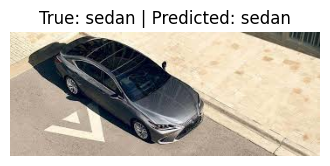

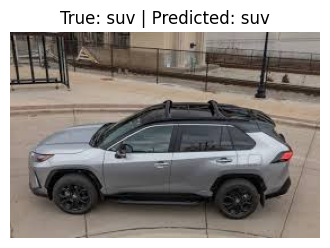

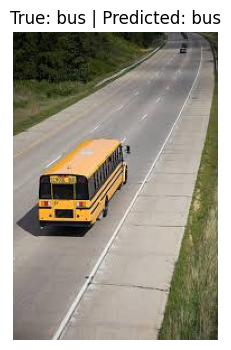

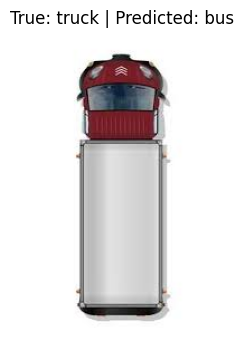

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

# Show results for each test image
for idx, row in df.iterrows():
    img = Image.open(row["image"])
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"True: {row['true_label']} | Predicted: {row['predicted_label']}")
    plt.axis("off")
    plt.show()

# Few-Shot Vehicle Classification with CLIP


## Model

- **Backbone:** CLIP Vision Transformer (OpenAI CLIP)
- **Purpose:** Used as a feature extractor to obtain high-dimensional, semantically rich image embeddings.
- **Why CLIP?**  
  CLIP is trained on image-text pairs, enabling it to learn robust visual representations that generalize well, especially in low-data regimes.

---


In [21]:
import torch
import pandas as pd
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Loading CLIP model...")
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)

def predict_with_text_prompts(image_path, class_names):
    image = Image.open(image_path).convert("RGB")
    prompts = [f"An overhead satellite, drone, or aerial view of a {cls} parked on the ground." for cls in class_names]
    inputs = processor(text=prompts, images=image, return_tensors="pt", padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
        img_emb = outputs.image_embeds
        txt_emb = outputs.text_embeds
        img_emb = img_emb / img_emb.norm(p=2, dim=-1, keepdim=True)
        txt_emb = txt_emb / txt_emb.norm(p=2, dim=-1, keepdim=True)
        sims = torch.matmul(img_emb, txt_emb.T)
        best_idx = sims.argmax().item()
    return class_names[best_idx]

def get_fused_embedding(image_path, label):
    image = Image.open(image_path).convert("RGB")
    clean_label = label.lower()
    master_prompt = f"An overhead satellite, drone, or aerial view of a {clean_label} on the ground."
    inputs = processor(text=[master_prompt], images=image, return_tensors="pt", padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
        img_features = outputs.image_embeds
        txt_features = outputs.text_embeds
        img_features = img_features / img_features.norm(p=2, dim=-1, keepdim=True)
        txt_features = txt_features / txt_features.norm(p=2, dim=-1, keepdim=True)
        fused_embedding = (img_features + txt_features) / 2.0
        fused_embedding = fused_embedding / fused_embedding.norm(p=2, dim=-1, keepdim=True)
    return fused_embedding

def build_memory_bank(context_data):
    print(f"Building FUSED Memory Bank from {len(context_data)} reference examples...")
    reference_embeddings = []
    reference_labels = []
    for img_path, label in context_data:
        clean_label = label.lower()
        emb = get_fused_embedding(img_path, clean_label)
        reference_embeddings.append(emb)
        reference_labels.append(clean_label)
    reference_matrix = torch.cat(reference_embeddings)
    return reference_matrix, reference_labels

def predict_new_image(image_path, reference_matrix, reference_labels):
    generic_label = "vehicle"
    emb = get_fused_embedding(image_path, generic_label)
    similarities = torch.matmul(emb, reference_matrix.T)
    best_match_index = similarities.argmax().item()
    predicted_label = reference_labels[best_match_index]
    return predicted_label

def predict_combined(image_path, class_names, ref_matrix, ref_labels):
    pred_text = predict_with_text_prompts(image_path, class_names)
    pred_img = predict_new_image(image_path, ref_matrix, ref_labels)
    if pred_text.lower() == pred_img.lower():
        return pred_text.lower()
    else:
        return pred_text.lower()

    # Image-to-image prediction and score
    generic_label = "vehicle"
    fused_emb = get_fused_embedding(image_path, generic_label)
    similarities = torch.matmul(fused_emb, ref_matrix.T).squeeze()
    img_best_idx = similarities.argmax().item()
    img_score = similarities[img_best_idx].item()
    img_pred = ref_labels[img_best_idx]

    # Choose prediction with higher confidence
    if img_score > text_score:
        return img_pred
    else:
        return text_pred

if __name__ == "__main__":
    # 1. YOUR MEMORY BANK
    examples = [
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-18-28_png.rf.28fc4b45cbb7cc0375a0a1d013da7acb.jpg", "SUV"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-14-51-53_png.rf.a420675aec9d267a4918e4f6b624b938.jpg", "SUV"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-14-49-01_png.rf.0a93df9f0be46f0eb90eac2282fc5347.jpg", "SUV"),
        (r"D:\CV_Project\data\cars.v1i.coco\crops\DJI-00760-00001-1-_jpg.rf.ccecf9a0ecc8984c01aaa5fa25516594_ann10.jpg", "SUV"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-17-59_png.rf.f83a7cd8ff5091d85bcd518ba63638ef.jpg", "sedan"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-14-44-24_png.rf.9ecb63672a6e06a87bf5875b063d626d.jpg", "sedan"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-02-04_png.rf.e778e47b1e388c7441c2fae1c630ec89.jpg", "sedan"),
        (r"D:\CV_Project\data\cars.v1i.coco\crops\DJI_0005-0071_jpg.rf.85e28363e268a259ced325858f5ea023_ann5.jpg", "sedan"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-05-15_png.rf.863275a545cedd225d0060f8e92e7fc7.jpg", "truck"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-04-52_png.rf.0d6db9bde6f4d40692ce4001d5010966.jpg", "truck"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-14-55-05_png.rf.da96e0c9ae878062bf8cf23474468091.jpg", "truck"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-14-54-08_png.rf.1fcb78dec3616ec5983678d61ed74729.jpg", "truck"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-17-07_png.rf.710f4176b646d40b2b99c564172586ca.jpg", "bus"),
        (r"D:\CV_Project\data\cars.v1i.coco\crops\Screenshot-from-2026-02-12-14-59-11_png.rf.b5726dd264543f89310fff9334907344_ann15.jpg", "bus"),
        (r"D:\CV_Project\data\cars.v1i.coco\crops\Screenshot-from-2026-02-12-14-58-26_png.rf.eca11b21c6c6bfd088b7970f4a99e3ac_ann18.jpg", "bus"),
        (r"D:\CV_Project\data\cars.v1i.coco\crops\DJI_0762-00031_jpg.rf.abb1115b71b8b0ff871968c8daf083ea_ann14.jpg", "bus"),
    ]

    # 2. YOUR TEST SET
    my_test_set = [
        (r"C:\Users\YASER\Documents\GitHub\Few-Shot-Vehicle-Detection-\test\sedan.png", "sedan"),
        (r"C:\Users\YASER\Documents\GitHub\Few-Shot-Vehicle-Detection-\test\SUV.png", "SUV"),
        (r"D:\CV_Project\test\bus.png", "bus"),
        (r"D:\CV_Project\test\truck.png", "truck"),
    ]

    class_names = ["bus", "sedan", "suv", "truck"]

    try:
        ref_matrix, ref_labels = build_memory_bank(examples)
        print(f"\nEvaluating {len(my_test_set)} test images...")
        predictions_log = []
        for img_path, true_label in my_test_set:
            pred = predict_combined(img_path, class_names, ref_matrix, ref_labels)
            predictions_log.append({
                "image": img_path,
                "true_label": true_label.lower(),
                "predicted_label": pred
            })
        df = pd.DataFrame(predictions_log)
        accuracy = accuracy_score(df["true_label"], df["predicted_label"])
        print(f"\n OVERALL ACCURACY: {accuracy * 100:.1f}%\n")
        print("--- Detailed Classification Report ---")
        print(classification_report(df["true_label"], df["predicted_label"], labels=class_names, target_names=class_names, zero_division=0))
        print("--- Confusion Matrix ---")
        print(confusion_matrix(df["true_label"], df["predicted_label"], labels=class_names))
    except Exception as e:
        print(f"\n Execution Error: {e}")

Loading CLIP model...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Building FUSED Memory Bank from 16 reference examples...

Evaluating 4 test images...

 OVERALL ACCURACY: 75.0%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         bus       0.50      1.00      0.67         1
       sedan       1.00      1.00      1.00         1
         suv       1.00      1.00      1.00         1
       truck       0.00      0.00      0.00         1

    accuracy                           0.75         4
   macro avg       0.62      0.75      0.67         4
weighted avg       0.62      0.75      0.67         4

--- Confusion Matrix ---
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [1 0 0 0]]


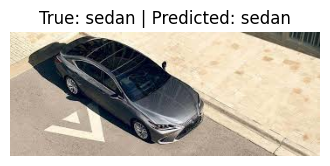

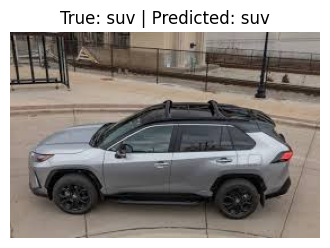

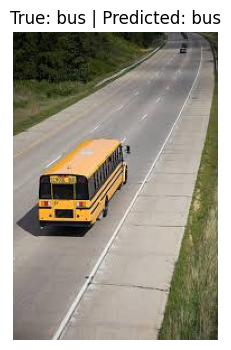

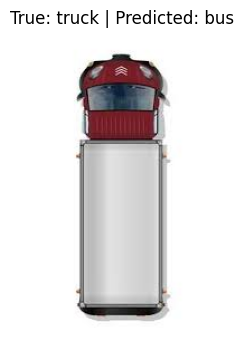

In [22]:
import matplotlib.pyplot as plt
from PIL import Image

# Show results for each test image
for idx, row in df.iterrows():
    img = Image.open(row["image"])
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"True: {row['true_label']} | Predicted: {row['predicted_label']}")
    plt.axis("off")
    plt.show()